In [1]:
import glob
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

from sklearn.impute import SimpleImputer

In [18]:
df_to_plot = pd.read_csv(
    "./Fig.S1.value.csv"
)


In [13]:
df_to_plot = df_to_plot <= 1e-8

df_to_plot = df_to_plot.iloc[np.argsort(-df_to_plot.sum(axis=1).values)]

df_to_plot = (
    df_to_plot.melt(ignore_index=False, var_name="Read Depth", value_name="Detectable")
    .reset_index()
    .rename(columns={"annot.symbol": "Associated gene"})
)

df_to_plot = df_to_plot.replace(True, "Yes").replace(False, "No")

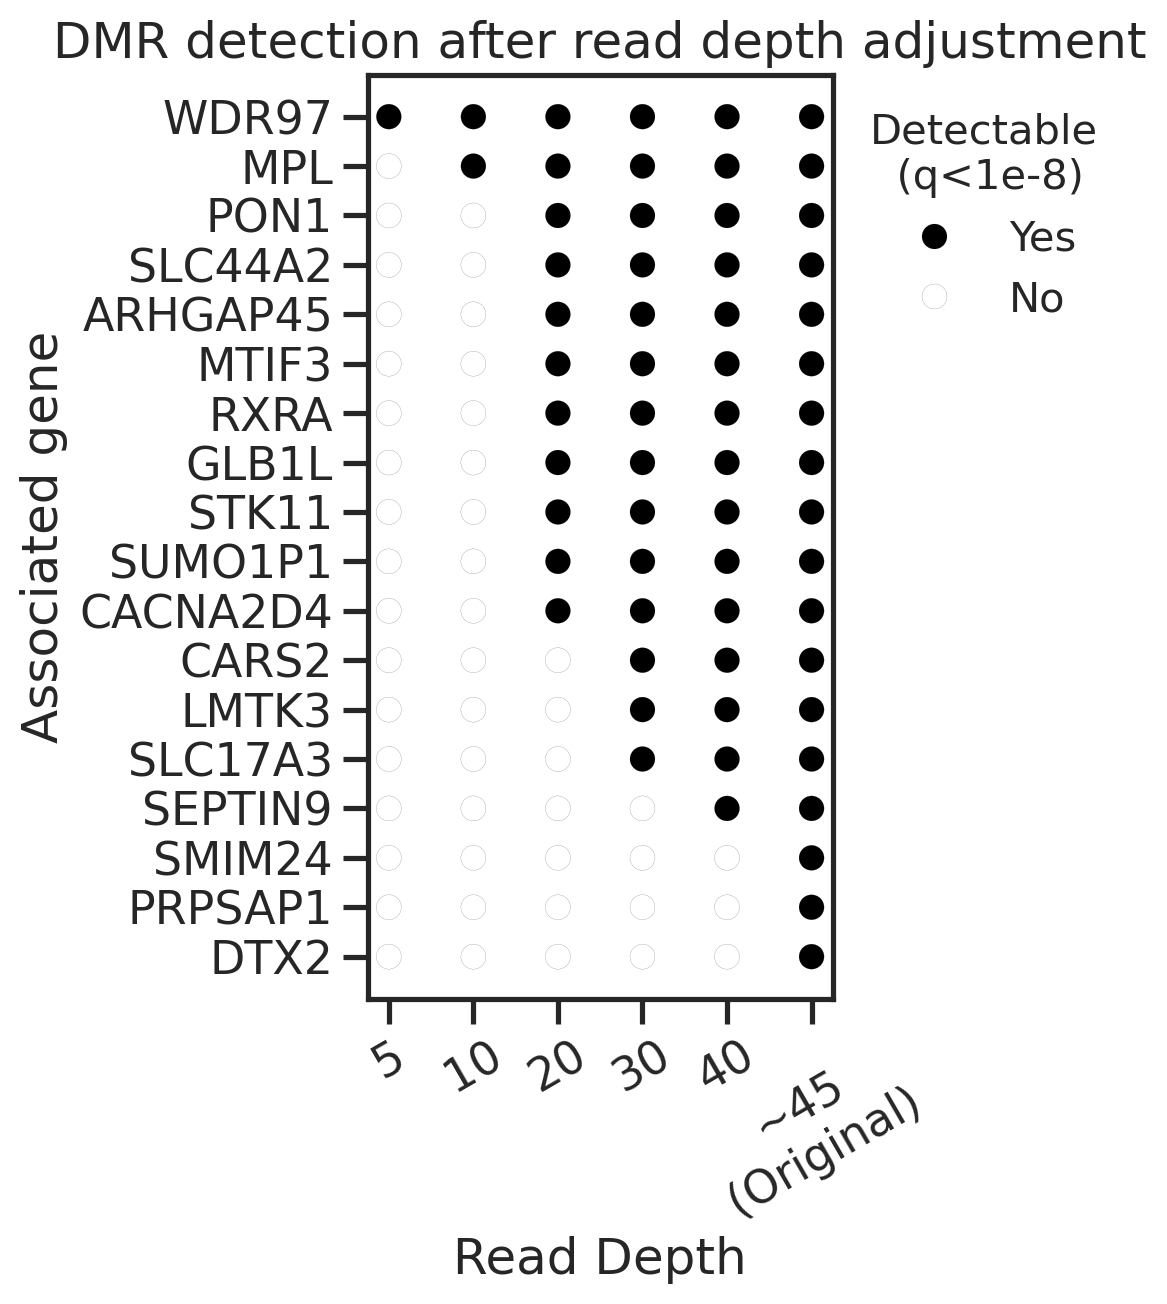

In [14]:
f, ax = plt.subplots(figsize=(3, 6))
sns.set_theme(context="talk", style="ticks")
sns.scatterplot(
    data=df_to_plot,
    hue="Detectable",
    y="Associated gene",
    x="Read Depth",
    ax=ax,
    edgecolor="black",
    palette=["black", "white"],
    linewidth=0.05,
)

plt.xticks(rotation=30)

# Add edge for marks in the legend by setting edgecolor in legend
sns.move_legend(
    ax,
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=15,
    title="Detectable\n  (q<1e-8)",
    title_fontsize=15,
)
legend = ax.get_legend()

# Update legend marker edges
for handle in legend.legend_handles:
    #handle.set_edgecolor("black")
    handle.set_linewidth(0.3)

ax.set(title="DMR detection after read depth adjustment")

f.savefig(
    "./Fig.S1.png",
    dpi=600,
    bbox_inches="tight",
)